# Task 7 - Sales Forecasting

Forecasting the weekly sales of 45 Walmart stores using time-based features and regression models.
Dataset: Walmart Sales Forecast from Kaggle (Aslan Ahmedov): train.csv, features.csv and stores.csv.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 1. Loading the data

In [ ]:
train = pd.read_csv("train.csv", parse_dates=["Date"])
features = pd.read_csv("features.csv", parse_dates=["Date"])
stores = pd.read_csv("stores.csv")

print("train:", train.shape)
print("features:", features.shape)
print("stores:", stores.shape)
train.head()

train: (421570, 5)
features: (8190, 12)
stores: (45, 3)


,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


## 2. Checking and combining the data
There are no missing sales values. The negative sales are returns, so I kept them. I added up all departments to get the total weekly sales of each store, then joined the store information and the weekly features (temperature, fuel price, CPI, unemployment). I did not use the MarkDown columns because most of their values are missing.

In [ ]:
print("Dates:", train["Date"].min().date(), "to", train["Date"].max().date())
print("Weeks:", train["Date"].nunique(), "| Stores:", train["Store"].nunique())
print("Missing in train:", train.isnull().sum().sum())
print("Negative sales rows:", (train["Weekly_Sales"] < 0).sum())
print()
print("Missing in features:")
print(features.isnull().sum())

Dates: 2010-02-05 to 2012-10-26
Weeks: 143 | Stores: 45
Missing in train: 0
Negative sales rows: 1285

Missing in features:
Store              0
Date               0
Temperature        0
Fuel_Price         0
MarkDown1       4158
MarkDown2       5269
MarkDown3       4577
MarkDown4       4726
MarkDown5       4140
CPI              585
Unemployment     585
IsHoliday          0
dtype: int64


In [ ]:
sales = train.groupby(["Store", "Date"], as_index=False).agg(
    Weekly_Sales=("Weekly_Sales", "sum"),
    IsHoliday=("IsHoliday", "max")
)

sales = sales.merge(features[["Store", "Date", "Temperature", "Fuel_Price", "CPI", "Unemployment"]],
                    on=["Store", "Date"], how="left")
sales = sales.merge(stores, on="Store", how="left")

print(sales.shape)
print("Missing after merge:", sales.isnull().sum().sum())
sales.head()

(6435, 10)
Missing after merge: 0


,Store,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,CPI,Unemployment,Type,Size
0,1,2010-02-05,1643690.90,False,42.31,2.572,211.096358,8.106,A,151315
1,1,2010-02-12,1641957.44,True,38.51,2.548,211.242170,8.106,A,151315
2,1,2010-02-19,1611968.17,False,39.93,2.514,211.289143,8.106,A,151315
3,1,2010-02-26,1409727.59,False,46.63,2.561,211.319643,8.106,A,151315
4,1,2010-03-05,1554806.68,False,46.50,2.625,211.350143,8.106,A,151315


## 3. Visualisation

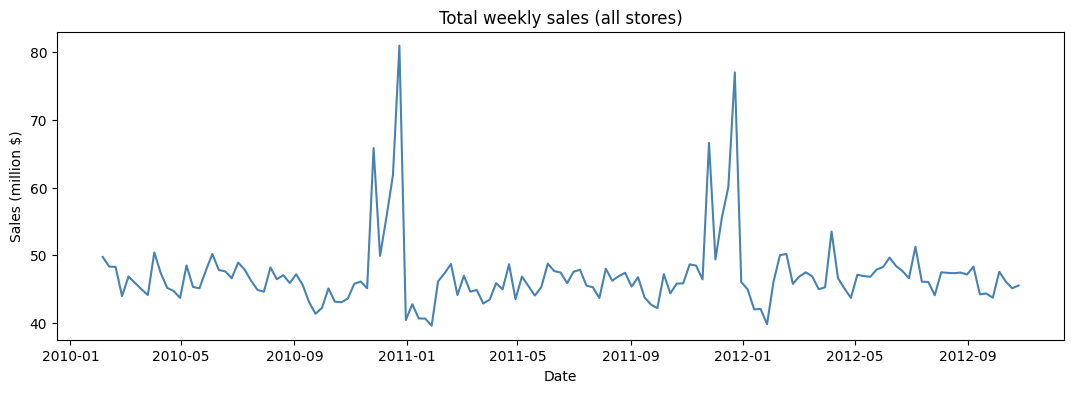

In [ ]:
weekly_total = sales.groupby("Date")["Weekly_Sales"].sum() / 1e6

plt.figure(figsize=(13, 4))
plt.plot(weekly_total.index, weekly_total.values, color="steelblue")
plt.title("Total weekly sales (all stores)")
plt.xlabel("Date")
plt.ylabel("Sales (million $)")
plt.show()

In [ ]:
print(sales.groupby("IsHoliday")["Weekly_Sales"].mean().round(0))

IsHoliday
False    1041256.0
True     1122888.0
Name: Weekly_Sales, dtype: float64


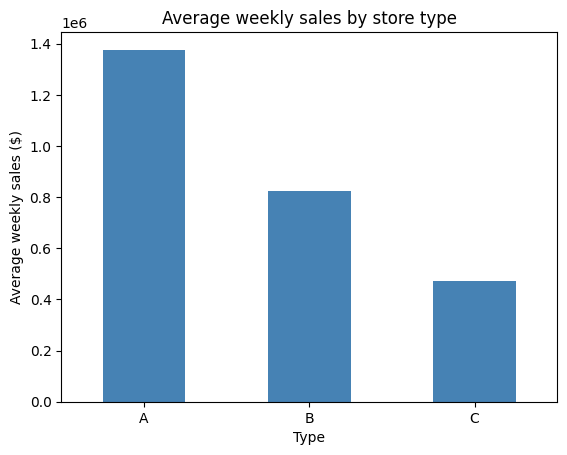

In [ ]:
sales.groupby("Type")["Weekly_Sales"].mean().plot(kind="bar", color="steelblue", rot=0)
plt.title("Average weekly sales by store type")
plt.ylabel("Average weekly sales ($)")
plt.show()

## 4. Time-based features
Year, month and week number, plus:
- Lag_1: the store's sales last week
- Lag_52: the store's sales in the same week last year
- Rolling_4: the average of the previous 4 weeks (a rolling average)

The lags are calculated separately for each store and only use past weeks.

In [ ]:
sales = sales.sort_values(["Store", "Date"]).reset_index(drop=True)

sales["Year"] = sales["Date"].dt.year
sales["Month"] = sales["Date"].dt.month
sales["Week"] = sales["Date"].dt.isocalendar().week.astype(int)

by_store = sales.groupby("Store")["Weekly_Sales"]
sales["Lag_1"] = by_store.shift(1)
sales["Lag_52"] = by_store.shift(52)
sales["Rolling_4"] = by_store.transform(lambda s: s.shift(1).rolling(4).mean())

sales["Type"] = sales["Type"].map({"A": 0, "B": 1, "C": 2})
sales["IsHoliday"] = sales["IsHoliday"].astype(int)

sales[["Store", "Date", "Weekly_Sales", "Lag_1", "Lag_52", "Rolling_4"]].head(6)

,Store,Date,Weekly_Sales,Lag_1,Lag_52,Rolling_4
0,1,2010-02-05,1643690.90,NaN,NaN,NaN
1,1,2010-02-12,1641957.44,1643690.90,NaN,NaN
2,1,2010-02-19,1611968.17,1641957.44,NaN,NaN
3,1,2010-02-26,1409727.59,1611968.17,NaN,NaN
4,1,2010-03-05,1554806.68,1409727.59,NaN,1576836.025
5,1,2010-03-12,1439541.59,1554806.68,NaN,1554614.970


## 5. Train/test split by date
For time series the split must follow time: the model is trained on the past (up to March 2012) and tested on the future (April to October 2012). The first year of each store is removed because it has no Lag_52.

In [ ]:
data = sales.dropna().copy()
print("Rows with all features:", data.shape, "| starts:", data["Date"].min().date())

cutoff = "2012-04-01"
train_df = data[data["Date"] < cutoff]
test_df = data[data["Date"] >= cutoff]

feature_cols = ["Store", "Type", "Size", "IsHoliday", "Temperature", "Fuel_Price", "CPI",
                "Unemployment", "Year", "Month", "Week", "Lag_1", "Lag_52", "Rolling_4"]

X_train, y_train = train_df[feature_cols], train_df["Weekly_Sales"]
X_test, y_test = test_df[feature_cols], test_df["Weekly_Sales"]

print("Train:", len(train_df), "rows, up to", train_df["Date"].max().date())
print("Test: ", len(test_df), "rows, from", test_df["Date"].min().date(), "to", test_df["Date"].max().date())

Rows with all features: (4095, 16) | starts: 2011-02-04
Train: 2745 rows, up to 2012-03-30
Test:  1350 rows, from 2012-04-06 to 2012-10-26


## 6. Models
I compared Linear Regression and Random Forest with a simple baseline that predicts last week's sales. MAPE is the average error as a percentage of the real sales.

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

def evaluate(name, pred):
    mae = mean_absolute_error(y_test, pred)
    r2 = r2_score(y_test, pred)
    mape = (abs(y_test - pred) / y_test).mean() * 100
    print(f"{name}: MAE ${mae:,.0f} | MAPE {mape:.2f}% | R² {r2:.3f}")

evaluate("Naive (last week)  ", test_df["Lag_1"])

lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
evaluate("Linear Regression  ", lr_pred)

rf = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
evaluate("Random Forest      ", rf_pred)

Naive (last week)  : MAE $58,628 | MAPE 5.55% | R² 0.971
Linear Regression  : MAE $54,186 | MAPE 5.92% | R² 0.978
Random Forest      : MAE $44,961 | MAPE 4.34% | R² 0.982


## 7. Actual vs predicted over time

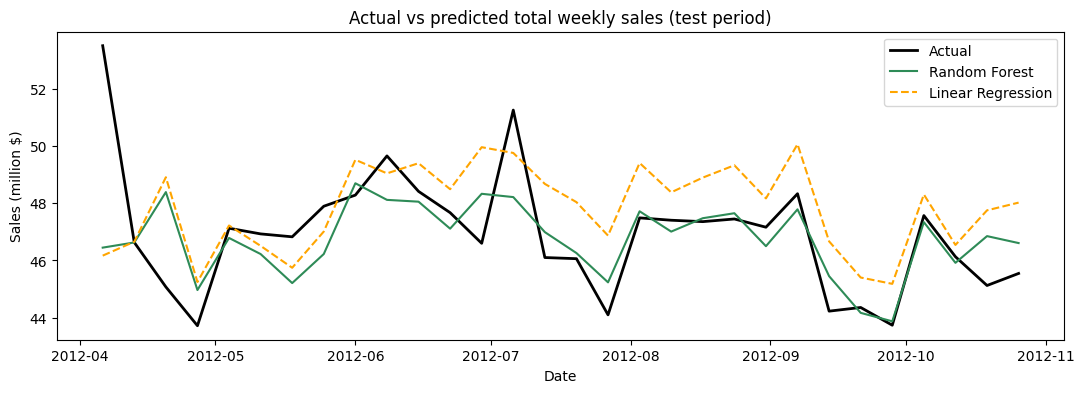

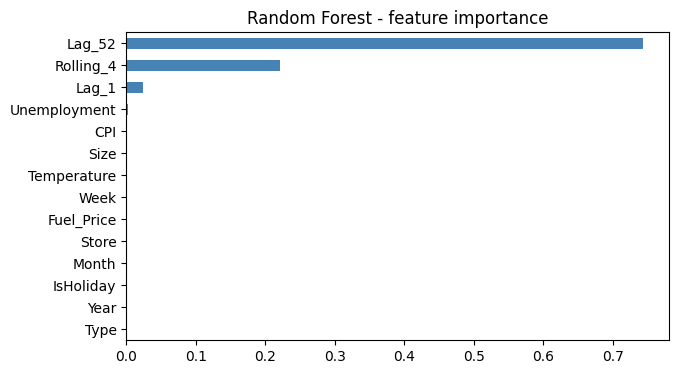

In [ ]:
results = test_df[["Date"]].copy()
results["Actual"] = y_test.values
results["Random Forest"] = rf_pred
results["Linear Regression"] = lr_pred
totals = results.groupby("Date").sum() / 1e6

plt.figure(figsize=(13, 4))
plt.plot(totals.index, totals["Actual"], label="Actual", color="black", linewidth=2)
plt.plot(totals.index, totals["Random Forest"], label="Random Forest", color="seagreen")
plt.plot(totals.index, totals["Linear Regression"], label="Linear Regression", color="orange", linestyle="--")
plt.title("Actual vs predicted total weekly sales (test period)")
plt.xlabel("Date")
plt.ylabel("Sales (million $)")
plt.legend()
plt.show()

importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values()
importances.plot(kind="barh", color="steelblue", figsize=(7, 4))
plt.title("Random Forest - feature importance")
plt.show()

## Conclusion

I combined the three files into the total weekly sales of each of the 45 stores (6,435 rows).
Sales are fairly stable during the year, with big spikes every year at Thanksgiving and
Christmas. Holiday weeks sell about 8% more on average, and type A stores sell the most.

I created time-based features (week, month, year), lag features (last week and the same week
last year) and a 4-week rolling average. The model was trained on data up to March 2012 and
tested on April to October 2012.

Results on the test period:
- Naive forecast (last week's sales): MAE \$58,628, MAPE 5.55%
- Linear Regression: MAE \$54,186, MAPE 5.92%
- Random Forest: MAE \$44,961, MAPE 4.34%

Random Forest was the best model, with an error about 23% lower than the naive forecast.
Linear Regression usually predicted too high. The most important feature was the sales
in the same week last year (Lag_52), followed by the 4-week rolling average.

Both models missed the sales spikes around Easter and the 4th of July, because these
holidays move to different weeks each year and are not marked in the IsHoliday column.
Adding them as holiday features could improve the forecasts.